Accuracy: 0.7556

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.56      0.69      0.62        13
   virginica       0.60      0.46      0.52        13

    accuracy                           0.76        45
   macro avg       0.72      0.72      0.71        45
weighted avg       0.76      0.76      0.75        45



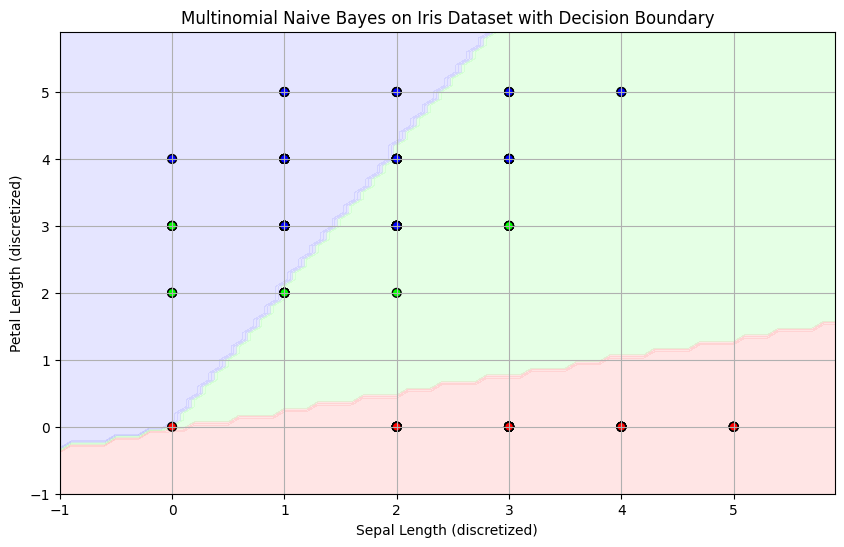

'Output -\nAccuracy: 0.7556\nClassification Report:\n              precision    recall  f1-score   support\n      setosa       1.00      1.00      1.00        19\n  versicolor       0.56      0.69      0.62        13\n   virginica       0.60      0.46      0.52        13\n\n    accuracy                           0.76        45\n   macro avg       0.72      0.72      0.71        45\nweighted avg       0.76      0.76      0.75        45\n'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from matplotlib.colors import ListedColormap
# 1. Load Iris dataset
iris = load_iris()
X = iris.data[:, [1,2]]
y = iris.target
# 2. Discretize features (MultinomialNB needs non-negative integers)
discretizer = KBinsDiscretizer(n_bins=6, encode='ordinal', strategy='uniform')
X_disc = discretizer.fit_transform(X)
# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_disc, y, test_size=0.3, random_state=42)
# 4. Train Multinomial Naive Bayes model
model = MultinomialNB()
model.fit(X_train, y_train)
# 5. Predict and evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=iris.target_names)
print(f"Accuracy: {accuracy:.4f}\n")
print("Classification Report:")
print(report)
# 6. Meshgrid for decision boundary
h = 0.1
x_min, x_max = X_disc[:, 0].min() - 1, X_disc[:, 0].max() + 1
y_min, y_max = X_disc[:, 1].min() - 1, X_disc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
# 7. Plot decision boundary
plt.figure(figsize=(10, 6))
cmap_light = ListedColormap(["#FFAAAA", "#AAFFAA", "#AAAAFF"])
cmap_bold = ListedColormap(["#FF0000", "#00FF00", "#0000FF"])
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
scatter = plt.scatter(X_disc[:, 0], X_disc[:, 1], c=y, cmap=cmap_bold, edgecolor="k", s=40)
plt.xlabel("Sepal Length (discretized)")
plt.ylabel("Petal Length (discretized)")
plt.title("Multinomial Naive Bayes on Iris Dataset with Decision Boundary")
plt.grid(True)
plt.show()
'''Output -
Accuracy: 0.7556
Classification Report:
              precision    recall  f1-score   support
      setosa       1.00      1.00      1.00        19
  versicolor       0.56      0.69      0.62        13
   virginica       0.60      0.46      0.52        13

    accuracy                           0.76        45
   macro avg       0.72      0.72      0.71        45
weighted avg       0.76      0.76      0.75        45
'''